# CPS access

[API user guide](https://www.census.gov/data/developers/guidance/api-user-guide.Available_Data.html#list-tab-559651575)

[CPS surveys list](https://api.census.gov/data.html)

[CPS 2020 variables](https://api.census.gov/data/2020/cps/asec/mar/variables.html) 
**Note:** When you open this link, you will get a list of variables. You can click on a variable name and get its description.

In [1]:
import numpy as np
import pandas as pd
import requests
import json
from matplotlib import pyplot as plt

In [2]:
filename = "..\\..\\Teaching\\Econ1193\\APIkeys.py"  #change this directory
%run $filename
key = os.environ['Census_API_key']

API keys loaded now


In [3]:
var_list = "WS_VAL,WSAL_VAL,TCERNVAL,TCWSVAL,A_SEX,PRDTRACE,A_AGE,A_HGA,A_EXPLF,PRDTRACE"

In [4]:
# consider adding A_MARITL:
# 1: "Marr-civ sp present"
# 2: "Marr-AF spo present"
# 3: "Marr-spouse absent"
# 4: "Widowed"
# 5: "Divorced"
# 6: "Separated"
# 7: "Never married"

In [5]:
#url2000 = "http://api.census.gov/data/2000/cps/asec/mar?get="+var_list+"&key="+key
#url2010 = "http://api.census.gov/data/2010/cps/asec/mar?get="+var_list+"&key="+key
url2020 = "http://api.census.gov/data/2020/cps/asec/mar?get="+var_list+"&key="+key


In [6]:
url2020

'http://api.census.gov/data/2020/cps/asec/mar?get=WS_VAL,WSAL_VAL,TCERNVAL,TCWSVAL,A_SEX,PRDTRACE,A_AGE,A_HGA,A_EXPLF,PRDTRACE&key=9affe801529d6f2fe6d4217bf84254af9e719f84'

In [7]:
r = requests.get(url2020).json()

In [8]:
print(f"raw data has {len(r)} observations")

raw data has 157960 observations


In [9]:
r

[['WS_VAL',
  'WSAL_VAL',
  'TCERNVAL',
  'TCWSVAL',
  'A_SEX',
  'PRDTRACE',
  'A_AGE',
  'A_HGA',
  'A_EXPLF',
  'PRDTRACE'],
 ['0', '52500', '0', '0', '2', '1', '63', '39', '1', '1'],
 ['0', '56000', '0', '0', '1', '1', '67', '39', '0', '1'],
 ['0', '34000', '0', '0', '1', '1', '64', '39', '1', '1'],
 ['0', '0', '0', '0', '2', '1', '71', '36', '0', '1'],
 ['0', '40000', '0', '0', '2', '1', '54', '39', '1', '1'],
 ['0', '0', '0', '0', '2', '1', '74', '39', '0', '1'],
 ['0', '8424', '0', '0', '1', '1', '37', '39', '1', '1'],
 ['0', '0', '0', '0', '2', '1', '47', '42', '0', '1'],
 ['0', '58000', '0', '0', '1', '1', '44', '40', '1', '1'],
 ['0', '0', '0', '0', '1', '1', '21', '39', '0', '1'],
 ['0', '0', '0', '0', '2', '1', '19', '40', '0', '1'],
 ['0', '0', '0', '0', '1', '1', '71', '39', '0', '1'],
 ['0', '0', '0', '0', '1', '1', '69', '39', '0', '1'],
 ['0', '0', '0', '0', '2', '1', '80', '40', '0', '1'],
 ['0', '42000', '0', '0', '2', '1', '35', '41', '1', '1'],
 ['0', '55000', '0',

In [10]:
columns = r[0]
data = r[1:]

df = pd.DataFrame(data, columns=columns)


In [11]:
df.head()

,WS_VAL,WSAL_VAL,TCERNVAL,TCWSVAL,A_SEX,PRDTRACE,A_AGE,A_HGA,A_EXPLF,PRDTRACE
0,0,52500,0,0,2,1,63,39,1,1
1,0,56000,0,0,1,1,67,39,0,1
2,0,34000,0,0,1,1,64,39,1,1
3,0,0,0,0,2,1,71,36,0,1
4,0,40000,0,0,2,1,54,39,1,1


In [35]:
df.tail()

,WS_VAL,WSAL_VAL,TCERNVAL,TCWSVAL,A_SEX,PRDTRACE,A_AGE,A_HGA,A_EXPLF,PRDTRACE
157954,0,0,0,0,2,5,72,40,0,5
157955,0,3187,0,0,2,4,50,43,0,4
157956,0,0,0,0,2,4,80,33,0,4
157957,0,120000,0,0,2,4,55,43,1,4
157958,0,0,0,0,1,8,12,0,0,8


In [12]:
# Convert numeric columns to numbers
df = df.apply(pd.to_numeric)

In [13]:
df.shape

(157959, 10)

In [14]:
# Keep only rows where A_SEX == 1
df_filtered = df[(df["A_SEX"] == 1) & (df["WSAL_VAL"]>0) & (df["A_AGE"].between(20, 50))].copy()

In [15]:
df_filtered.shape

(24905, 10)

In [16]:
df_filtered.head(10)

,WS_VAL,WSAL_VAL,TCERNVAL,TCWSVAL,A_SEX,PRDTRACE,A_AGE,A_HGA,A_EXPLF,PRDTRACE
6,0,8424,0,0,1,1,37,39,1,1
8,0,58000,0,0,1,1,44,40,1,1
15,0,55000,0,0,1,1,37,43,1,1
47,0,30000,0,0,1,1,39,41,1,1
56,1500,20500,0,0,1,1,27,39,1,1
61,0,55000,0,0,1,1,43,39,1,1
72,0,60000,0,0,1,1,48,39,1,1
78,0,8000,0,0,1,1,33,39,2,1
86,0,65000,0,0,1,1,34,43,1,1
88,0,25000,0,0,1,1,35,43,1,1


In [17]:
df_filtered.TCERNVAL.sum()

228

In [18]:
df_filtered.TCWSVAL.sum()

88

In [19]:
df_filtered.WS_VAL.sum()

47270910

In [20]:
educ_dict = {
    0 : "Children",
    31 : "Less Than 1st Grade",
    32 : "1st,2nd,3rd,or 4th grade",
    33 : "5th Or 6th Grade",
    34 : "7th and 8th grade",
    35 : "9th Grade",
    36 : "10th Grade",
    37 : "11th Grade",
    38 : "12th Grade No Diploma",
    39 : "High school graduate-high school diploma",
    40 : "Some College But No Degree",
    41 : "Assc degree-occupation/vocation",
    42 : "Assc degree-academic program",
    43 : "Bachelor's degree (BA,AB,BS)",
    44 : "Master's degree (MA,MS,MENG,MED,MSW,MBA)",
    45 : "Professional school degree (MD,DDS,DVM,L",
    46 : "Doctorate degree (PHD,EDD)"
}

In [21]:
df_filtered['educ_description'] = df_filtered['A_HGA'].map(educ_dict)

In [22]:
df_filtered.head()

,WS_VAL,WSAL_VAL,TCERNVAL,TCWSVAL,A_SEX,PRDTRACE,A_AGE,A_HGA,A_EXPLF,PRDTRACE,educ_description
6,0,8424,0,0,1,1,37,39,1,1,High school graduate-high school diploma
8,0,58000,0,0,1,1,44,40,1,1,Some College But No Degree
15,0,55000,0,0,1,1,37,43,1,1,"Bachelor's degree (BA,AB,BS)"
47,0,30000,0,0,1,1,39,41,1,1,Assc degree-occupation/vocation
56,1500,20500,0,0,1,1,27,39,1,1,High school graduate-high school diploma


In [23]:
educ_years_dict = {
    0:  0,   # Children
    31: 0,   # Less Than 1st Grade
    32: 4,   # 1st–4th grade (top of range)
    33: 6,   # 5th–6th grade (top of range)
    34: 8,   # 7th–8th grade (top of range)
    35: 9,   # 9th Grade
    36: 10,  # 10th Grade
    37: 11,  # 11th Grade
    38: 12,  # 12th Grade No Diploma
    39: 12,  # High school diploma
    40: 14,  # Some College (no degree)
    41: 14,  # Associate's degree (14 years = 12 + 2)
    42: 14,  # Associate's degree academic
    43: 16,  # Bachelor's degree (12 + 4)
    44: 18,  # Master's degree (16 + 2)
    45: 20,  # Professional degree (16 + 4)
    46: 20,  # Doctorate (16 + 4)
}

In [24]:
df_filtered['educ_numeric'] = df_filtered['A_HGA'].map(educ_years_dict)

In [25]:
df_filtered.head()

,WS_VAL,WSAL_VAL,TCERNVAL,TCWSVAL,A_SEX,PRDTRACE,A_AGE,A_HGA,A_EXPLF,PRDTRACE,educ_description,educ_numeric
6,0,8424,0,0,1,1,37,39,1,1,High school graduate-high school diploma,12
8,0,58000,0,0,1,1,44,40,1,1,Some College But No Degree,14
15,0,55000,0,0,1,1,37,43,1,1,"Bachelor's degree (BA,AB,BS)",16
47,0,30000,0,0,1,1,39,41,1,1,Assc degree-occupation/vocation,14
56,1500,20500,0,0,1,1,27,39,1,1,High school graduate-high school diploma,12


In [26]:
work_dict = {
        0 : "Not in experienced labor force",
    1 : "Employed",
    2 : "Unemployed"
}


In [27]:
df_filtered['wor_status'] = df_filtered['A_EXPLF'].map(work_dict)

In [28]:
df_filtered.head()

,WS_VAL,WSAL_VAL,TCERNVAL,TCWSVAL,A_SEX,PRDTRACE,A_AGE,A_HGA,A_EXPLF,PRDTRACE,educ_description,educ_numeric,wor_status
6,0,8424,0,0,1,1,37,39,1,1,High school graduate-high school diploma,12,Employed
8,0,58000,0,0,1,1,44,40,1,1,Some College But No Degree,14,Employed
15,0,55000,0,0,1,1,37,43,1,1,"Bachelor's degree (BA,AB,BS)",16,Employed
47,0,30000,0,0,1,1,39,41,1,1,Assc degree-occupation/vocation,14,Employed
56,1500,20500,0,0,1,1,27,39,1,1,High school graduate-high school diploma,12,Employed


### Saving the data

In [29]:
### Saving to a file
df_filtered.to_csv('cps2020.csv', index=False)

In [30]:
df_filtered.columns

Index(['WS_VAL', 'WSAL_VAL', 'TCERNVAL', 'TCWSVAL', 'A_SEX', 'PRDTRACE',
       'A_AGE', 'A_HGA', 'A_EXPLF', 'PRDTRACE', 'educ_description',
       'educ_numeric', 'wor_status'],
      dtype='object')

### Additional operations

In [31]:
sex_dict = {1: 'Male', 2: 'Female'}
df_filtered.groupby(df_filtered['A_SEX'].map(sex_dict))['WSAL_VAL'].describe()

,count,mean,std,min,25%,50%,75%,max
A_SEX,,,,,,,,
Male,24905.0,66957.422847,79407.260696,2.0,29000.0,50000.0,80000.0,1115000.0


In [32]:
import matplotlib.pyplot as plt

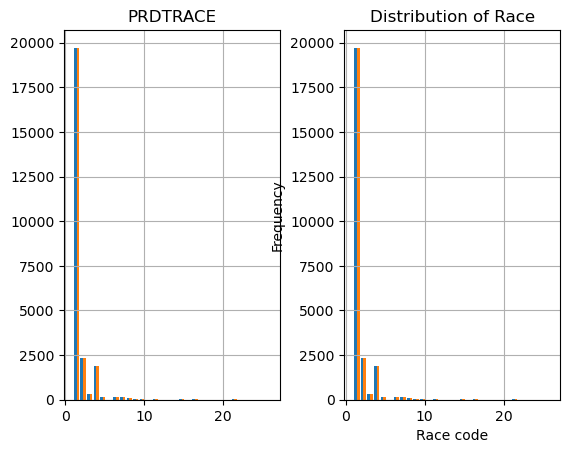

In [33]:
df_filtered['PRDTRACE'].hist(bins=30)
plt.xlabel('Race code')
plt.ylabel('Frequency')
plt.title('Distribution of Race')
plt.show()

In [34]:
df_filtered['PRDTRACE'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%'

ValueError: Grouper for 'PRDTRACE' not 1-dimensional

In [36]:
race_dict = {
    1:  "White Only",
    2:  "Black Only",
    3:  "American Indian, Alaskan Native Only",
    4:  "Asian Only",
    5:  "Hawaiian/Pacific Islander Only",
    6:  "White-Black",
    7:  "White-AI",
    8:  "White-Asian",
    9:  "White-HP",
    10: "Black-AI",
    11: "Black-Asian",
    12: "Black-HP",
    13: "AI-Asian",
    14: "AI-HP",
    15: "Asian-HP",
    16: "W-B-AI",
    17: "W-B-A",
    18: "W-B-HP",
    19: "W-AI-A",
    20: "W-AI-HP",
    21: "W-A-HP",
    22: "B-AI-A",
    23: "W-B-AI-A",
    24: "W-AI-A-HP",
    25: "Other 3 Race Combinations",
    26: "Other 4 and 5 Race Combinations"
}

In [37]:
df_filtered['PRDTRACE'].map(race_dict).value_counts(normalize=True) * 100

AttributeError: 'DataFrame' object has no attribute 'map'